# Yield Curve Construction and Economic Recession

# Part 1: Data clean

### The Data here was gain by using excel with Bloomberg (BDH formula)

### U.S Treasury of 3M/2Y/5Y/10Y/30Y from 1995-01-01 to 2025-04-01

### First we read the raw data and see how bad it is

In [1]:
import pandas as pd

data = pd.read_excel("/Users/klauswei/Desktop/BU/2025_Spring/MF728_Fixed_Income/final_project/USGG_raw.xlsx")

data.head(5)

,USGG,Unnamed: 1,3M,Unnamed: 3,2Y,Unnamed: 5,5y,Unnamed: 7,10Y,Unnamed: 9,30Y
0,NaN,1995-01-02,5.687,1995-01-02,7.699,1995-01-02,7.835,1995-01-02,7.831,1995-01-02,7.879
1,NaN,1995-01-03,5.655,1995-01-03,7.725,1995-01-03,7.873,1995-01-03,7.875,1995-01-03,7.919
2,NaN,1995-01-04,5.848,1995-01-04,7.621,1995-01-04,7.812,1995-01-04,7.815,1995-01-04,7.851
3,NaN,1995-01-05,5.889,1995-01-05,7.647,1995-01-05,7.862,1995-01-05,7.854,1995-01-05,7.882
4,NaN,1995-01-06,5.907,1995-01-06,7.621,1995-01-06,7.866,1995-01-06,7.858,1995-01-06,7.860


### Define all the maturites and corresponding columns

In [2]:
t_cols = {
    "3M" : [1,2],
    "2Y" : [3,4],
    "5Y" : [5,6],
    "10Y" : [7,8],
    "30Y" : [9,10],
}

### Take out each of them and merge the date col

In [3]:
from functools import reduce

cleaned_data = []

for t, (date, rate) in t_cols.items():
    subset = data.iloc[:, [date, rate]].copy()
    subset.columns = ["Date" , t]
    subset = subset.dropna()
    cleaned_data.append(subset)

merged_data = reduce(lambda left, right: pd.merge(left, right, on = "Date", how = "outer"), cleaned_data)

merged_data = merged_data.sort_values("Date").reset_index(drop = True)

merged_data.head(5)

,Date,3M,2Y,5Y,10Y,30Y
0,1995-01-02,5.687,7.699,7.835,7.831,7.879
1,1995-01-03,5.655,7.725,7.873,7.875,7.919
2,1995-01-04,5.848,7.621,7.812,7.815,7.851
3,1995-01-05,5.889,7.647,7.862,7.854,7.882
4,1995-01-06,5.907,7.621,7.866,7.858,7.860


### Now it looks good, but let use check again

In [4]:
merged_data.isna().sum()

Date    0
3M      2
2Y      2
5Y      2
10Y     2
30Y     3
dtype: int64

### Apply interpolate for missing value, using Spline here

In [5]:
merged_data.iloc[:,1:] = merged_data.iloc[:, 1:].interpolate(method = "spline", order = 3, axis = 0)

merged_data.isna().sum()

Date    0
3M      0
2Y      0
5Y      0
10Y     0
30Y     0
dtype: int64

### Now the data looks ready!

# Part 2: Apply Nelson-Siegel Model to approximate 

### Goal: Use data to approximate entire yield curve efficiently and capture its level, slope, and curvature.
### Nelson-Siegel Model

$$
y(\tau) = \beta_0 + \beta_1 \cdot \frac{1 - e^{-\lambda \tau}}{\lambda \tau} + \beta_2 \cdot \left( \frac{1 - e^{-\lambda \tau}}{\lambda \tau} - e^{-\lambda \tau} \right)
$$

### Beta0: Capture the long-term level of rates
### Beta1: Capture the short-term slope of the curve
### Beta2: Capture the medium-term curvature
### Lambda: Control the decay rate and how fast the curve flatten

In [8]:
merged_data.head()

,Date,3M,2Y,5Y,10Y,30Y
0,1995-01-02,5.687,7.699,7.835,7.831,7.879
1,1995-01-03,5.655,7.725,7.873,7.875,7.919
2,1995-01-04,5.848,7.621,7.812,7.815,7.851
3,1995-01-05,5.889,7.647,7.862,7.854,7.882
4,1995-01-06,5.907,7.621,7.866,7.858,7.860


In [9]:
import numpy as np

maturities = np.array([0.25, 2, 5, 10, 30])
rate_cols = ['3M', '2Y', '5Y', '10Y', '30Y']

### Define Nelson-Siegel 

In [10]:
def nelson_siegel(tau, beta0, beta1, beta2, lambda_):
    term1 = (1 - np.exp(-tau / lambda_)) / (tau / lambda_)
    term2 = term1 - np.exp(-tau / lambda_)
    return beta0 + beta1 * term1 + beta2 * term2

### Define loss

In [11]:
def ns_loss(params, tau, y_obs):
    beta0, beta1, beta2, lambda_ = params
    y_fit = nelson_siegel(tau, beta0, beta1, beta2, lambda_)
    return np.sum((y_obs - y_fit) ** 2)

### Initialize parameters and bounds

In [12]:
init_params = [0.02, -0.01, 0.01, 1.0]
bounds = [(-5, 5), (-5, 5), (-5, 5), (0.01, 10)]

In [13]:
from scipy.optimize import minimize

results = []

for idx, row in merged_data.iterrows():
    yields = row[rate_cols].values / 100 
    res = minimize(ns_loss, init_params, args=(maturities, yields), bounds=bounds)
    if res.success:
        beta0, beta1, beta2, lambda_ = res.x
        fitted_yields = nelson_siegel(maturities, beta0, beta1, beta2, lambda_)
        rmse = np.sqrt(np.mean((fitted_yields - yields) ** 2))
    else:
        beta0, beta1, beta2, lambda_ = [np.nan]*4
        rmse = np.nan
    results.append([row['Date'], beta0, beta1, beta2, lambda_, rmse])

data_ns = pd.DataFrame(results, columns=['Date', 'Beta0', 'Beta1', 'Beta2', 'Lambda', 'RMSE'])

data_ns.head()

,Date,Beta0,Beta1,Beta2,Lambda,RMSE
0,1995-01-02,0.077885,-0.027904,0.035566,0.999559,0.000562
1,1995-01-03,0.078306,-0.028841,0.036385,0.999533,0.000558
2,1995-01-04,0.077936,-0.025520,0.030039,0.999797,0.000360
3,1995-01-05,0.078327,-0.025494,0.029865,0.999821,0.000282
4,1995-01-06,0.078291,-0.025182,0.029105,0.999865,0.000151


# Part 3: Extension to Nelson-Siegel-Svensson Model

## Reasons: NSS could add one more curvature term, so that the model could be more reliable.

$$
y(\tau) = \beta_0 + \beta_1 \left( \frac{1 - e^{-\lambda_1 \tau}}{\lambda_1 \tau} \right) + \beta_2 \left( \frac{1 - e^{-\lambda_1 \tau}}{\lambda_1 \tau} - e^{-\lambda_1 \tau} \right) + \beta_3 \left( \frac{1 - e^{-\lambda_2 \tau}}{\lambda_2 \tau} - e^{-\lambda_2 \tau} \right)
$$

In [14]:
def nss_yield(tau, beta0, beta1, beta2, beta3, lambda_, c):
    term1 = beta0
    term2 = beta1 * (1 - np.exp(-lambda_ * tau)) / (lambda_ * tau)
    term3 = beta2 * ((1 - np.exp(-lambda_ * tau)) / (lambda_ * tau) - np.exp(-lambda_ * tau))
    term4 = beta3 * ((1 - np.exp(-c * tau)) / (c * tau) - np.exp(-c * tau))
    return term1 + term2 + term3 + term4

In [15]:
def loss_nss(params, maturities, yields):
    beta0, beta1, beta2, beta3, lambda_, c = params
    fitted = nss_yield(np.array(maturities), beta0, beta1, beta2, beta3, lambda_, c)
    return np.sqrt(np.mean(((fitted - yields)* 100) ** 2))

In [16]:
nss_results = []

for idx, row in merged_data.iterrows():
    yields = row[rate_cols].values / 100
    nss_init_params = [1.5, -1, 1, 0.5, 0.5, 0.5]
    nss_bounds = [(-10, 10), (-10, 10), (-10, 10), (-10, 10), (0.001, 5), (0.001, 5)]

    nss_res = minimize(loss_nss, nss_init_params, args=(maturities, yields), bounds=nss_bounds, method='L-BFGS-B')

    if nss_res.success:
        nss_result_row = {
            'Date': row['Date'],
            'beta0': nss_res.x[0], 'beta1': nss_res.x[1], 'beta2': nss_res.x[2],
            'beta3': nss_res.x[3], 'lambda': nss_res.x[4], 'c': nss_res.x[5],
            'rmse': nss_res.fun
        }
        nss_results.append(nss_result_row)

In [17]:
data_nss = pd.DataFrame(nss_results)
data_nss['Date'] = pd.to_datetime(data_nss['Date'])

data_nss.head()

,Date,beta0,beta1,beta2,beta3,lambda,c,rmse
0,1995-01-02,-0.011248,0.060955,0.184950,0.074337,0.045478,0.793169,0.000001
1,1995-01-03,0.364715,-0.312468,0.380944,0.086549,0.002093,0.466927,0.143130
2,1995-01-04,0.300349,-0.245499,0.359123,0.075086,0.002091,0.450390,0.115824
3,1995-01-05,0.288620,-0.233336,0.353604,0.074969,0.002134,0.445746,0.110016
4,1995-01-06,-0.023190,0.076739,0.192833,0.062618,0.040338,0.709860,0.000004


# Part 3.5: Comparison Analysis between NS & NSS

## Nelson_Siegel Paras

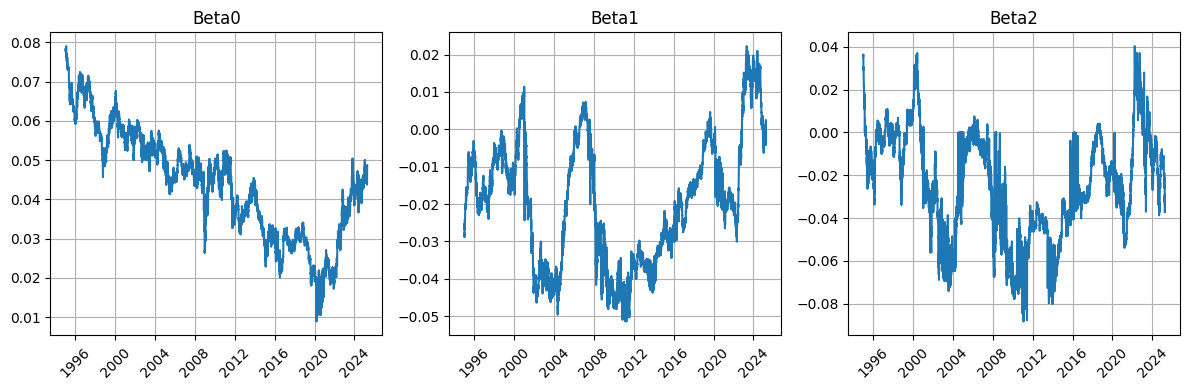

In [18]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 4))
for i, param in enumerate(['Beta0', 'Beta1', 'Beta2']):
    plt.subplot(1, 3, i+1)
    plt.plot(data_ns['Date'], data_ns[param])
    plt.title(param)
    plt.xticks(rotation=45)
    plt.grid(True)
plt.tight_layout()
plt.show()

# NSS Paras

array([[<Axes: >, <Axes: >],
       [<Axes: >, <Axes: >]], dtype=object)

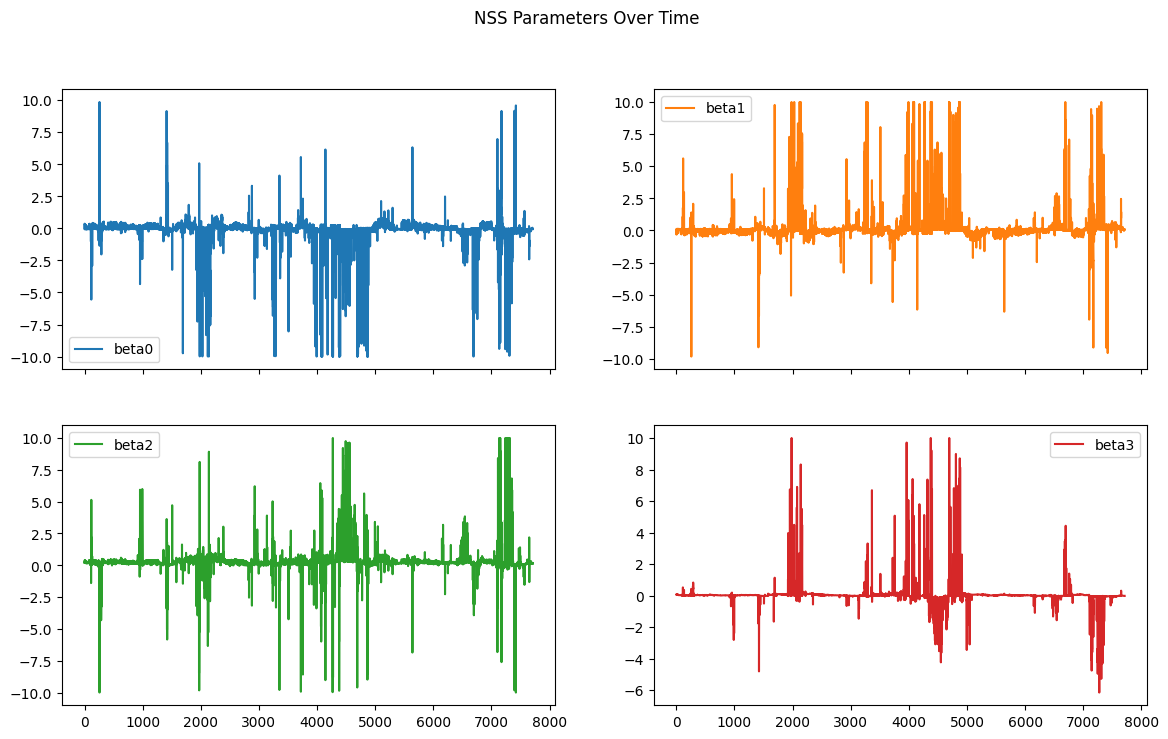

In [19]:
data_nss[['beta0', 'beta1', 'beta2', 'beta3']].plot(subplots=True, layout=(2,2), figsize=(14,8), title="NSS Parameters Over Time")

<Axes: title={'center': 'RMSE Comparison (NS vs NSS)'}>

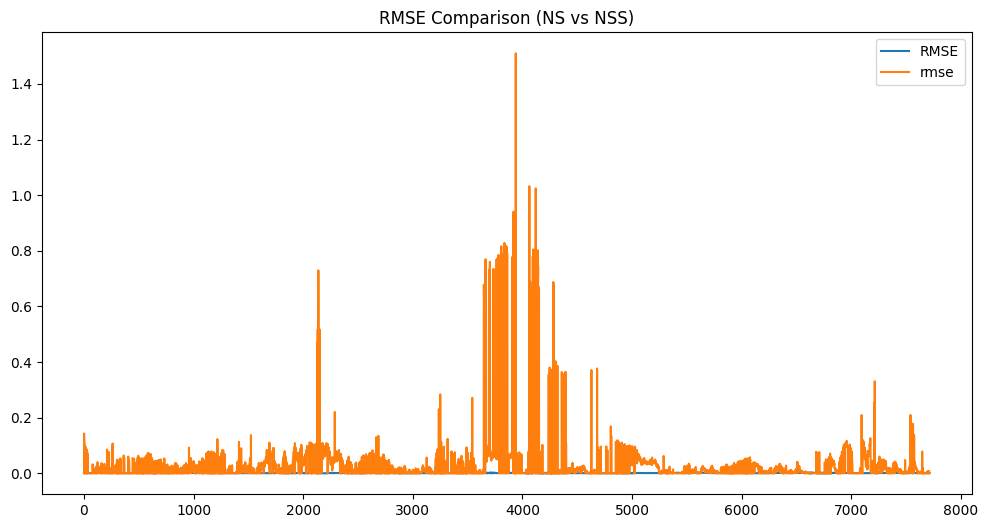

In [20]:
merged_rmse = pd.merge(data_ns[['RMSE']], data_nss[['rmse']], left_index=True, right_index=True, suffixes=('_NS', '_NSS'))
merged_rmse.plot(title="RMSE Comparison (NS vs NSS)", figsize=(12, 6))

Text(0.5, 1.0, 'NS vs NSS RMSE')

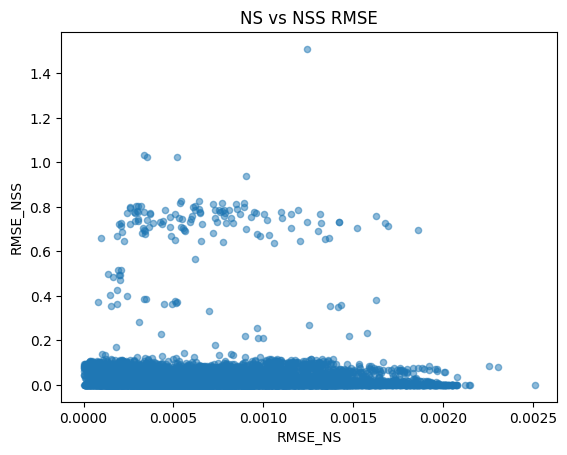

In [36]:
merged_rmse = pd.DataFrame(index=data_ns.index.intersection(data_nss.index))
merged_rmse['RMSE_NS'] = data_ns.loc[merged_rmse.index, 'RMSE']
merged_rmse['RMSE_NSS'] = data_nss.loc[merged_rmse.index, 'rmse']

merged_rmse.plot.scatter(x='RMSE_NS', y='RMSE_NSS', alpha=0.5)
plt.title("NS vs NSS RMSE")

## NS model vs. NSS model

# Part 4: Visulization

### Heatmap

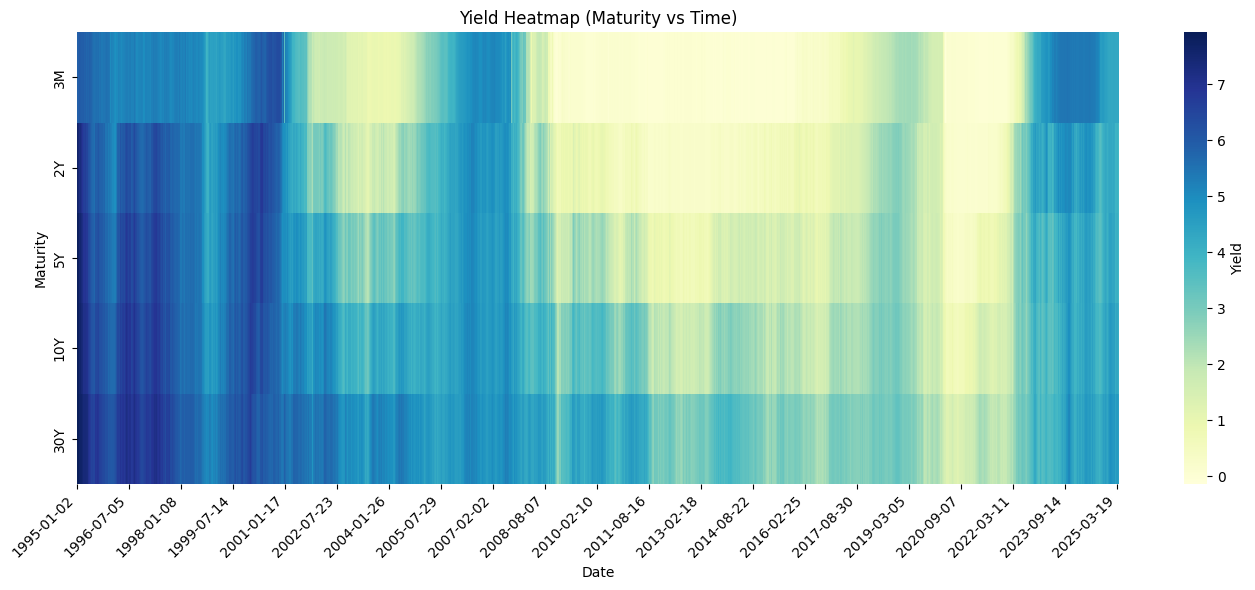

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

dates = pd.to_datetime(merged_data['Date'])
rate_data = merged_data[rate_cols].set_index(dates)


plt.figure(figsize=(14, 6))
ax = sns.heatmap(rate_data.T, cmap="YlGnBu", cbar_kws={'label': 'Yield'})

n_dates = len(rate_data)
tick_spacing = max(n_dates // 20, 1)
xtick_locs = np.arange(0, n_dates, tick_spacing)
xtick_labels = dates.dt.strftime('%Y-%m-%d').values[::tick_spacing]

ax.set_xticks(xtick_locs)
ax.set_xticklabels(xtick_labels, rotation=45, ha='right')

plt.title("Yield Heatmap (Maturity vs Time)")
plt.xlabel("Date")
plt.ylabel("Maturity")
plt.tight_layout()
plt.show()

# Part 5: Construct Recession Indicator

In [25]:
merged_data["10Y-2Y"] = merged_data["10Y"] - merged_data["2Y"]
merged_data["10Y-3M"] = merged_data["10Y"] - merged_data["3M"]

In [26]:
recession_indicator = pd.read_csv("/Users/klauswei/Desktop/BU/2025_Spring/MF728_Fixed_Income/final_project/USREC.csv")
print(recession_indicator.columns)
print(merged_data.columns)

recession_indicator["observation_date"] = pd.to_datetime(recession_indicator["observation_date"])
recession_indicator = recession_indicator.rename(columns={"observation_date": "Date", "USREC": "Recession"})

merged_data = pd.merge(merged_data, recession_indicator, on="Date", how="left")
merged_data["Recession"] = merged_data["Recession"].fillna(0)

Index(['observation_date', 'USREC'], dtype='object')
Index(['Date', '3M', '2Y', '5Y', '10Y', '30Y', '10Y-2Y', '10Y-3M'], dtype='object')


In [27]:
# CPI
cpi = pd.read_csv("/Users/klauswei/Desktop/BU/2025_Spring/MF728_Fixed_Income/final_project/CPIAUCSL.csv")
cpi = cpi.rename(columns={"observation_date": "Date", "CPIAUCSL": "CPI"})
cpi["Date"] = pd.to_datetime(cpi["Date"])
cpi = cpi[["Date", "CPI"]]

# Unemployment
unrate = pd.read_csv("/Users/klauswei/Desktop/BU/2025_Spring/MF728_Fixed_Income/final_project/UNRATE.csv")
unrate = unrate.rename(columns={"observation_date": "Date", "UNRATE": "Unemployment"})
unrate["Date"] = pd.to_datetime(unrate["Date"])
unrate = unrate[["Date", "Unemployment"]]

# GDPC1
gdp = pd.read_csv('/Users/klauswei/Desktop/BU/2025_Spring/MF728_Fixed_Income/final_project/GDPC1.csv')
gdp = gdp.rename(columns={"observation_date": "Date", "GDPC1": "GDP"})
gdp["Date"] = pd.to_datetime(gdp["Date"])
gdp = gdp[["Date", "GDP"]]

# INDPRO
ind = pd.read_csv('/Users/klauswei/Desktop/BU/2025_Spring/MF728_Fixed_Income/final_project/INDPRO.csv')
ind = ind.rename(columns={"observation_date": "Date", "INDPRO": "IND"})
ind["Date"] = pd.to_datetime(ind["Date"])
ind = ind[["Date", "IND"]]

# ICSA
icsa = pd.read_csv('/Users/klauswei/Desktop/BU/2025_Spring/MF728_Fixed_Income/final_project/ICSA.csv')
icsa = icsa.rename(columns={"observation_date": "Date"})
icsa["Date"] = pd.to_datetime(icsa["Date"])
icsa = icsa[["Date", "ICSA"]]
icsa = icsa.set_index("Date").sort_index()
icsa = icsa.resample('D').ffill()


print(merged_data.columns)

Index(['Date', '3M', '2Y', '5Y', '10Y', '30Y', '10Y-2Y', '10Y-3M',
       'Recession'],
      dtype='object')


In [28]:
merged_data = pd.merge(merged_data, cpi, on="Date", how="left")
merged_data = pd.merge(merged_data, unrate, on="Date", how="left")
merged_data = pd.merge(merged_data, gdp, on="Date", how="left")
merged_data = pd.merge(merged_data, ind, on="Date", how="left")
merged_data = pd.merge(merged_data, icsa, on="Date", how="left")

print(merged_data.columns)

Index(['Date', '3M', '2Y', '5Y', '10Y', '30Y', '10Y-2Y', '10Y-3M', 'Recession',
       'CPI', 'Unemployment', 'GDP', 'IND', 'ICSA'],
      dtype='object')


In [29]:
merged_data.isna().sum() 

Date               0
3M                 0
2Y                 0
5Y                 0
10Y                0
30Y                0
10Y-2Y             0
10Y-3M             0
Recession          0
CPI             7639
Unemployment    7639
GDP             7813
IND             7639
ICSA               9
dtype: int64

In [30]:
merged_data["CPI_YoY"] = merged_data["CPI"].pct_change(periods=12) * 100

merged_data["Unemployment"] = merged_data["Unemployment"].ffill()

merged_data['GDP_YoY'] = merged_data['GDP'].pct_change(4) * 100

merged_data['IND_YoY'] = merged_data['IND'].pct_change(12) * 100

merged_data['ICSA_smooth'] = -np.log(merged_data['ICSA'].rolling(7).mean())

merged_data.isna().sum()

/var/folders/0x/m7zdg5ws40d82m_y7djyss7r0000gn/T/ipykernel_18105/2838951881.py:1: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  merged_data["CPI_YoY"] = merged_data["CPI"].pct_change(periods=12) * 100
/var/folders/0x/m7zdg5ws40d82m_y7djyss7r0000gn/T/ipykernel_18105/2838951881.py:5: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  merged_data['GDP_YoY'] = merged_data['GDP'].pct_change(4) * 100
/var/folders/0x/m7zdg5ws40d82m_y7djyss7r0000gn/T/ipykernel_18105/2838951881.py:7: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either

Date               0
3M                 0
2Y                 0
5Y                 0
10Y                0
30Y                0
10Y-2Y             0
10Y-3M             0
Recession          0
CPI             7639
Unemployment      22
GDP             7813
IND             7639
ICSA               9
CPI_YoY           34
GDP_YoY          264
IND_YoY           34
ICSA_smooth       15
dtype: int64

### 10Y-3M vs. CPI

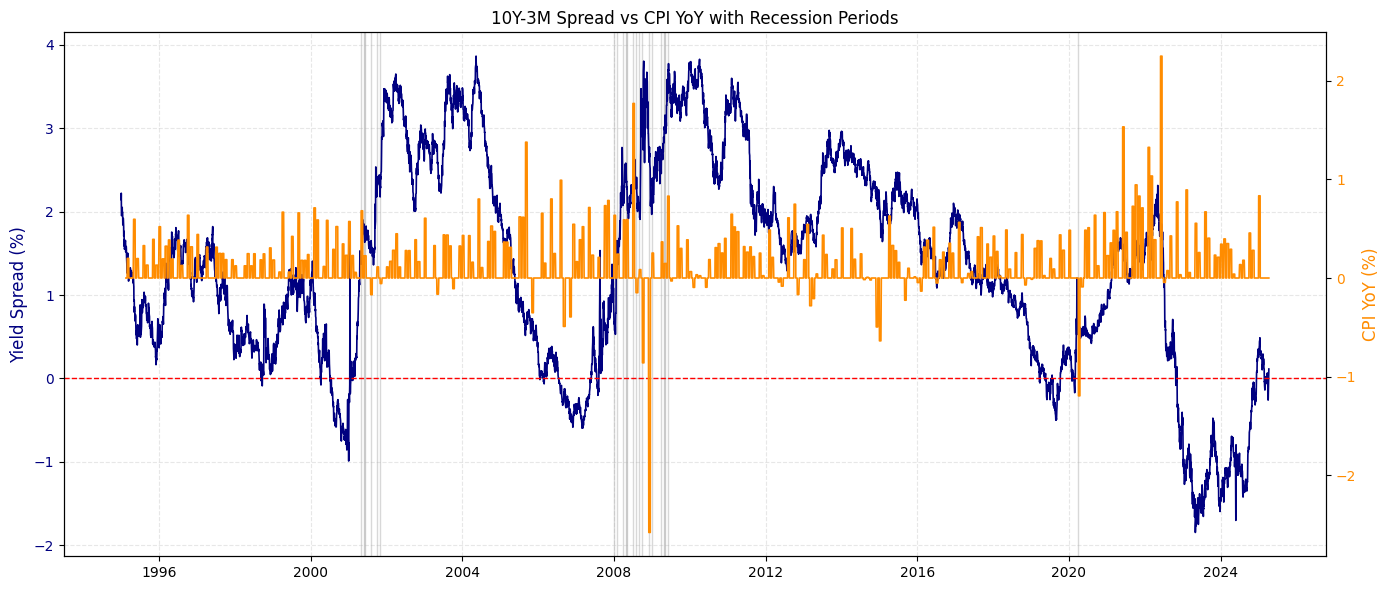

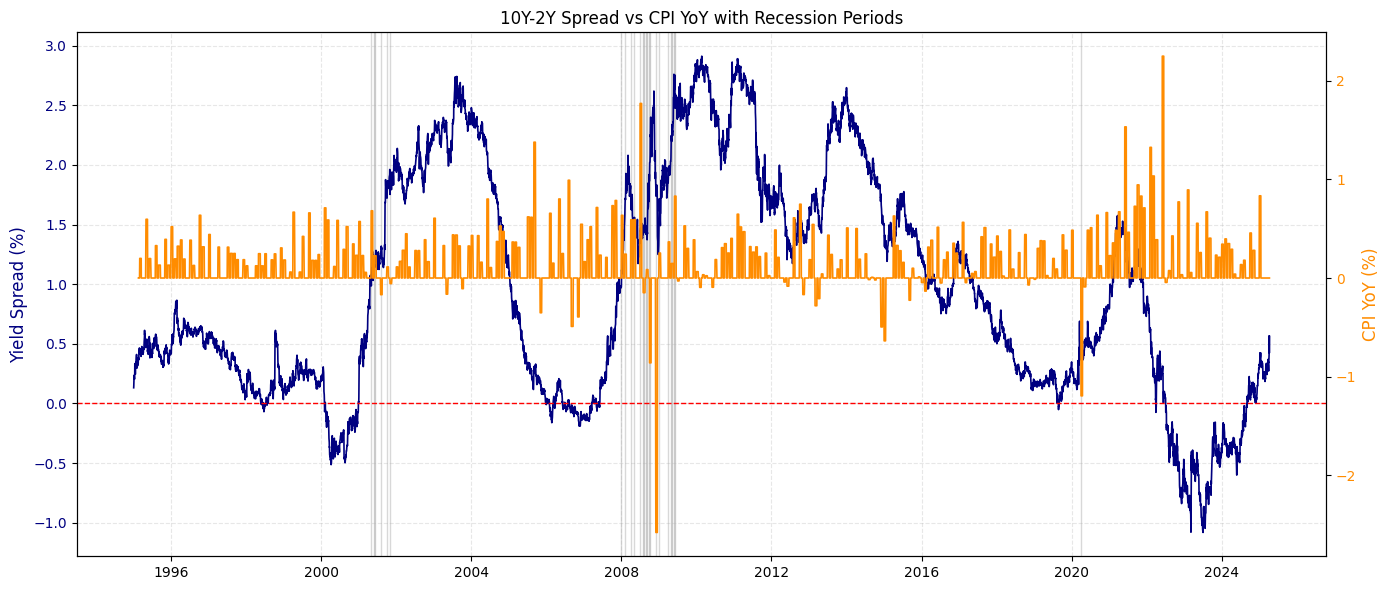

In [31]:
def plot_spread_vs_cpi(spread_col: str, title: str):
    fig, ax1 = plt.subplots(figsize=(14, 6))
    ax1.plot(merged_data["Date"], merged_data[spread_col], label=spread_col, color="navy", linewidth=1.2)
    ax1.axhline(0, color="red", linestyle="--", linewidth=1)
    ax1.set_ylabel("Yield Spread (%)", color="navy", fontsize=12)
    ax1.tick_params(axis='y', labelcolor="navy")
    ax1.grid(True, linestyle="--", alpha=0.3)

    ax2 = ax1.twinx()
    ax2.plot(merged_data["Date"], merged_data["CPI_YoY"], label="CPI YoY (%)", color="darkorange", linewidth=1.2)
    ax2.set_ylabel("CPI YoY (%)", color="darkorange", fontsize=12)
    ax2.tick_params(axis='y', labelcolor="darkorange")

    recession_mask = merged_data["Recession"] == 1
    for i in range(1, len(recession_mask)):
        if recession_mask.iloc[i] and not recession_mask.iloc[i - 1]:
            start = merged_data["Date"].iloc[i]
        if not recession_mask.iloc[i] and recession_mask.iloc[i - 1]:
            end = merged_data["Date"].iloc[i]
            ax1.axvspan(start, end, color="gray", alpha=0.3)

    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_spread_vs_cpi("10Y-3M", "10Y-3M Spread vs CPI YoY with Recession Periods")
plot_spread_vs_cpi("10Y-2Y", "10Y-2Y Spread vs CPI YoY with Recession Periods")


### 10Y-3M & 10Y-2Y vs. Unemployment rate

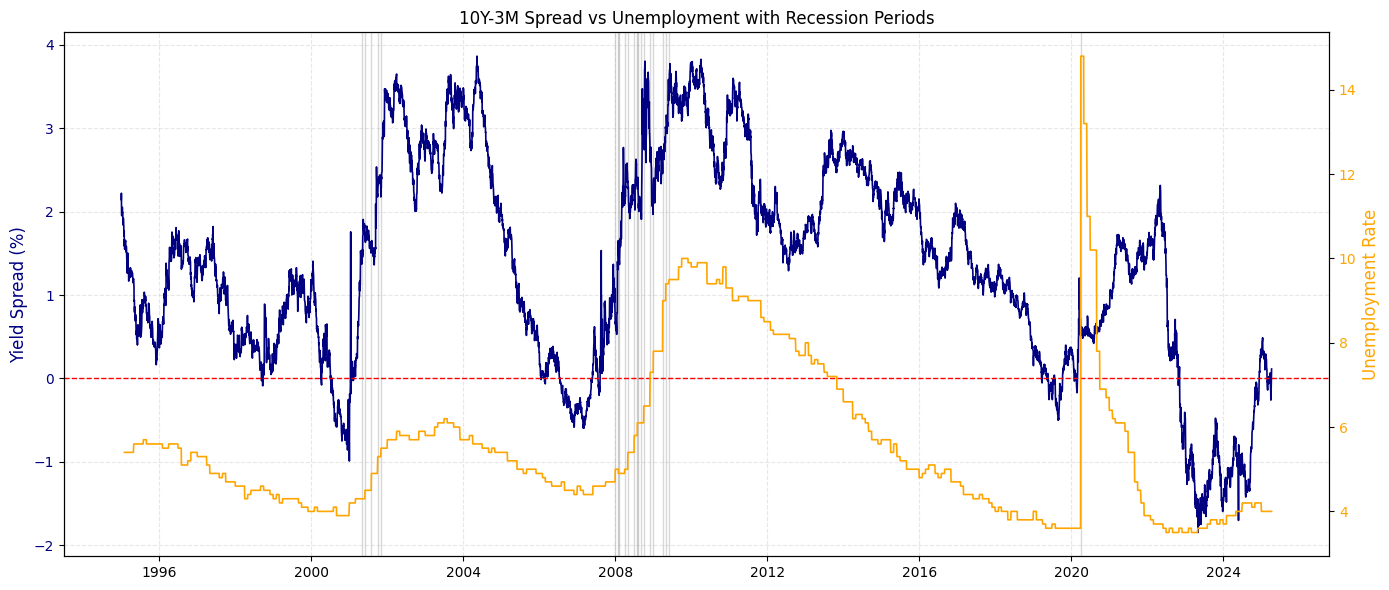

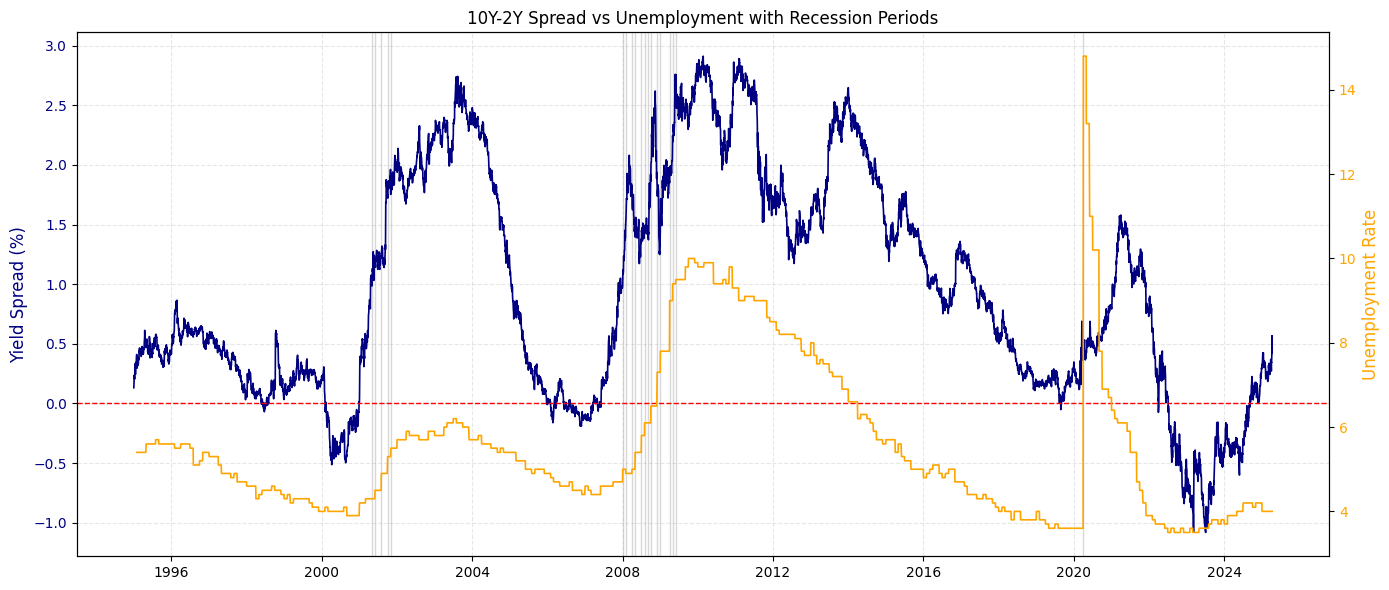

In [32]:
def plot_spread_vs_une(spread_col: str, title: str):
    fig, ax1 = plt.subplots(figsize = (14, 6))
    ax1.plot(merged_data["Date"], merged_data[spread_col], label=spread_col, color="navy", linewidth=1.2)
    ax1.axhline(0, color="red", linestyle="--", linewidth=1)
    ax1.set_ylabel("Yield Spread (%)", color="navy", fontsize=12)
    ax1.tick_params(axis='y', labelcolor="navy")
    ax1.grid(True, linestyle="--", alpha=0.3)
    

    ax2 = ax1.twinx()
    ax2.plot(merged_data["Date"], merged_data["Unemployment"], label="UNE", color="orange", linewidth=1.2)
    ax2.set_ylabel("Unemployment Rate", color="orange", fontsize = 12)
    ax2.tick_params(axis='y', labelcolor="orange")

    recession_mask = merged_data["Recession"] == 1
    for i in range(1, len(recession_mask)):
        if recession_mask.iloc[i] and not recession_mask.iloc[i - 1]:
            start = merged_data["Date"].iloc[i]
        if not recession_mask.iloc[i] and recession_mask.iloc[i - 1]:
            end = merged_data["Date"].iloc[i]
            ax1.axvspan(start, end, color="gray", alpha=0.3)

    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_spread_vs_une("10Y-3M", "10Y-3M Spread vs Unemployment with Recession Periods")
plot_spread_vs_une("10Y-2Y", "10Y-2Y Spread vs Unemployment with Recession Periods")

### 10Y-3M & 10Y-2Y vs. GDP

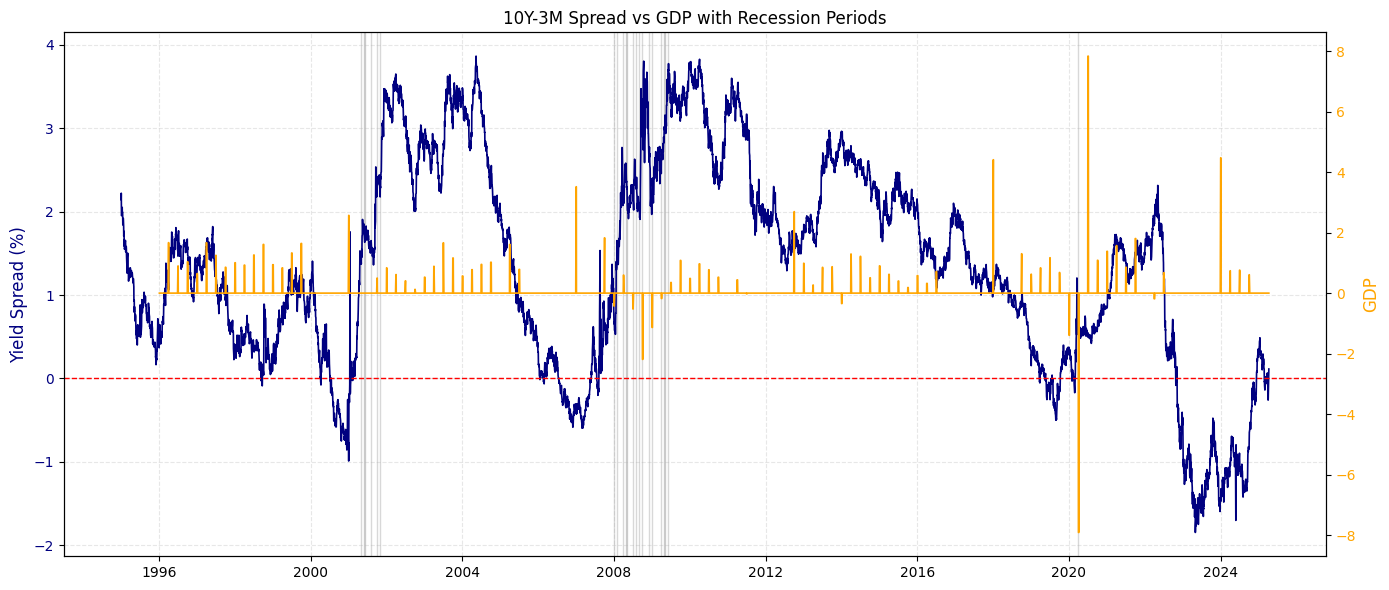

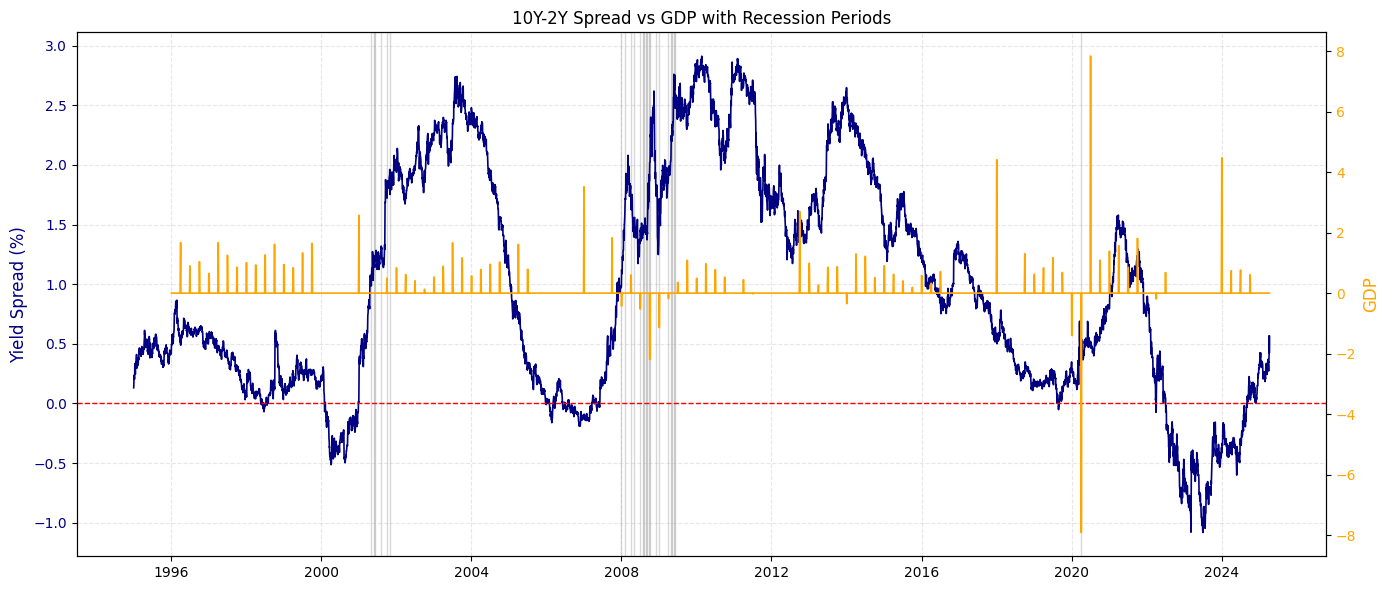

In [33]:
def plot_spread_vs_gdp(spread_col: str, title: str):
    fig, ax1 = plt.subplots(figsize = (14, 6))
    ax1.plot(merged_data["Date"], merged_data[spread_col], label=spread_col, color="navy", linewidth=1.2)
    ax1.axhline(0, color="red", linestyle="--", linewidth=1)
    ax1.set_ylabel("Yield Spread (%)", color="navy", fontsize=12)
    ax1.tick_params(axis='y', labelcolor="navy")
    ax1.grid(True, linestyle="--", alpha=0.3)
    

    ax2 = ax1.twinx()
    ax2.plot(merged_data["Date"], merged_data["GDP_YoY"], label="GDP_YoY", color="orange", linewidth=1.2)
    ax2.set_ylabel("GDP", color="orange", fontsize = 12)
    ax2.tick_params(axis='y', labelcolor="orange")

    recession_mask = merged_data["Recession"] == 1
    for i in range(1, len(recession_mask)):
        if recession_mask.iloc[i] and not recession_mask.iloc[i - 1]:
            start = merged_data["Date"].iloc[i]
        if not recession_mask.iloc[i] and recession_mask.iloc[i - 1]:
            end = merged_data["Date"].iloc[i]
            ax1.axvspan(start, end, color="gray", alpha=0.3)

    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_spread_vs_gdp("10Y-3M", "10Y-3M Spread vs GDP with Recession Periods")
plot_spread_vs_gdp("10Y-2Y", "10Y-2Y Spread vs GDP with Recession Periods")

### 10Y-3M & 10Y-2Y vs. INDPRO

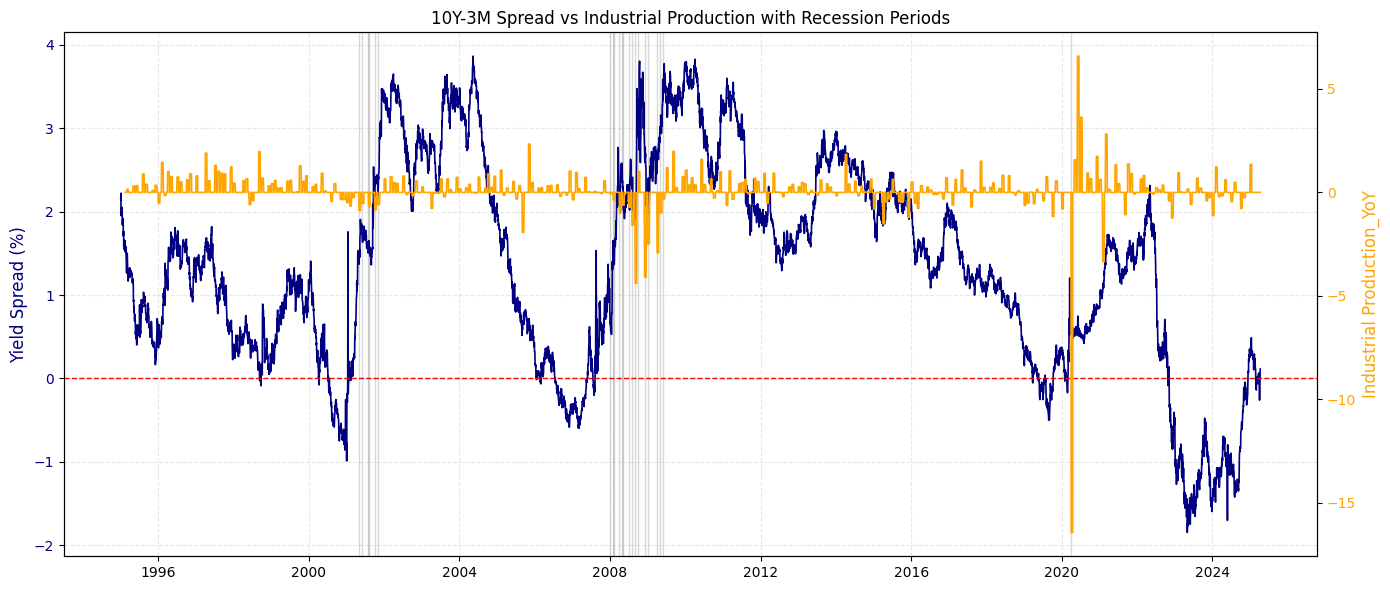

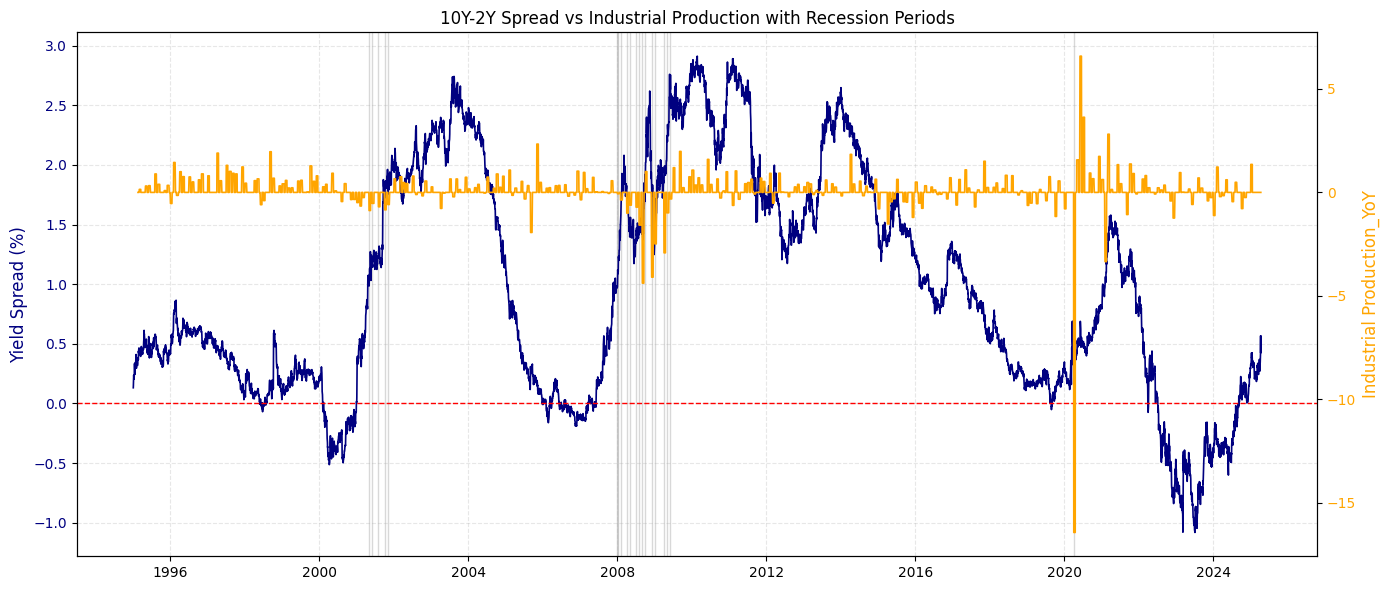

In [34]:
def plot_spread_vs_ind(spread_col: str, title: str):
    fig, ax1 = plt.subplots(figsize = (14, 6))
    ax1.plot(merged_data["Date"], merged_data[spread_col], label=spread_col, color="navy", linewidth=1.2)
    ax1.axhline(0, color="red", linestyle="--", linewidth=1)
    ax1.set_ylabel("Yield Spread (%)", color="navy", fontsize=12)
    ax1.tick_params(axis='y', labelcolor="navy")
    ax1.grid(True, linestyle="--", alpha=0.3)
    

    ax2 = ax1.twinx()
    ax2.plot(merged_data["Date"], merged_data["IND_YoY"], label="IND_YoY", color="orange", linewidth=1.2)
    ax2.set_ylabel("Industrial Production_YoY", color="orange", fontsize = 12)
    ax2.tick_params(axis='y', labelcolor="orange")

    recession_mask = merged_data["Recession"] == 1
    for i in range(1, len(recession_mask)):
        if recession_mask.iloc[i] and not recession_mask.iloc[i - 1]:
            start = merged_data["Date"].iloc[i]
        if not recession_mask.iloc[i] and recession_mask.iloc[i - 1]:
            end = merged_data["Date"].iloc[i]
            ax1.axvspan(start, end, color="gray", alpha=0.3)

    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_spread_vs_ind("10Y-3M", "10Y-3M Spread vs Industrial Production with Recession Periods")
plot_spread_vs_ind("10Y-2Y", "10Y-2Y Spread vs Industrial Production with Recession Periods")

### 10Y-3M & 10Y-2Y vs. ICSA

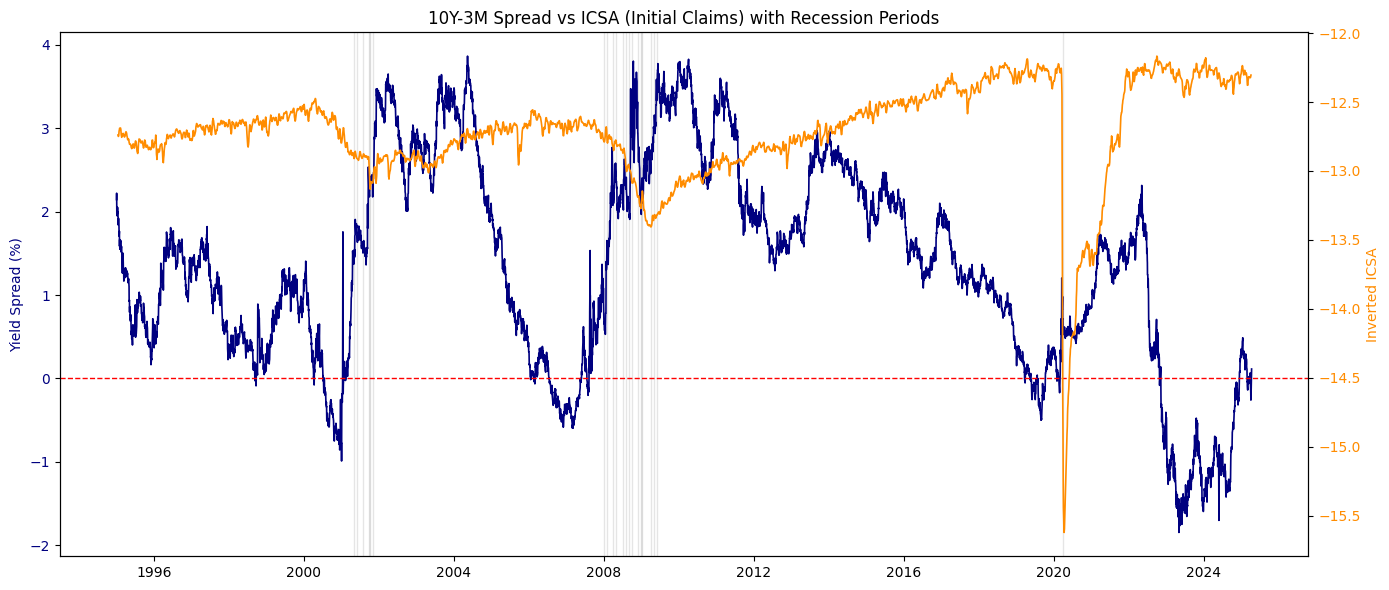

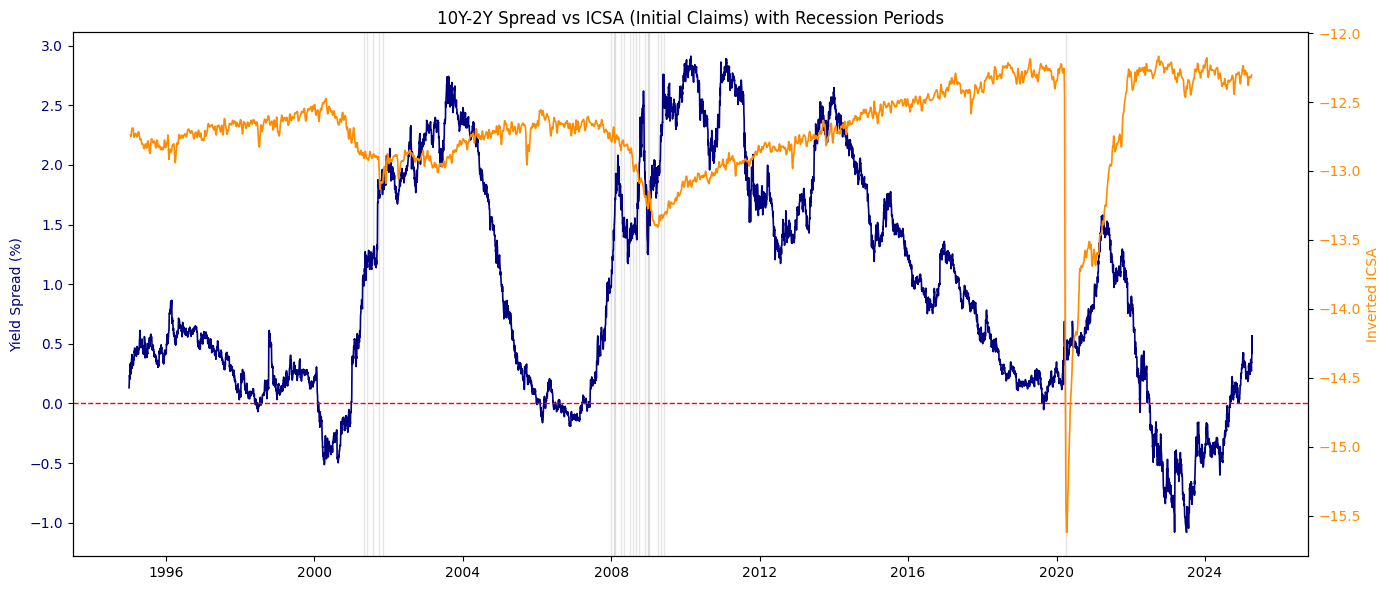

In [35]:
def plot_spread_vs_icsa(spread_col: str, title: str):
    fig, ax1 = plt.subplots(figsize=(14, 6))

    ax1.plot(merged_data["Date"], merged_data[spread_col], color="navy", label=spread_col, linewidth=1.2)
    ax1.axhline(0, color="red", linestyle="--", linewidth=1)
    ax1.set_ylabel("Yield Spread (%)", color="navy")
    ax1.tick_params(axis="y", labelcolor="navy")

    ax2 = ax1.twinx()
    ax2.plot(merged_data["Date"], merged_data["ICSA_smooth"], color="darkorange", label="Inverted ICSA (4W avg)", linewidth=1.2)
    ax2.set_ylabel("Inverted ICSA", color="darkorange")
    ax2.tick_params(axis="y", labelcolor="darkorange")

    # 灰条 recession
    recession_mask = merged_data["Recession"] == 1
    for i in range(1, len(recession_mask)):
        if recession_mask.iloc[i] and not recession_mask.iloc[i - 1]:
            start = merged_data["Date"].iloc[i]
        if not recession_mask.iloc[i] and recession_mask.iloc[i - 1]:
            end = merged_data["Date"].iloc[i]
            ax1.axvspan(start, end, color="gray", alpha=0.2)

    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_spread_vs_icsa("10Y-3M", "10Y-3M Spread vs ICSA (Initial Claims) with Recession Periods")
plot_spread_vs_icsa("10Y-2Y", "10Y-2Y Spread vs ICSA (Initial Claims) with Recession Periods")